# 03 — Evaluation metrics

Loads the trained model and reproduces **test-set metrics**: confusion matrix (image), classification report, **ROC-AUC**, and **feature importances**.

Requires `ml/model.pkl` and `ml/feature_columns.pkl` (from notebook 02 or `ml/train_model.py`).

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, *ROOT.parents]:
    if (candidate / "ml" / "model.pkl").is_file():
        os.chdir(candidate)
        break
else:
    raise FileNotFoundError("Train the model first (notebook 02 or python ml/train_model.py)")
print("CWD:", os.getcwd())

CWD: B:\PBCS\VI Sem\Machine Learning\MiniProject\Final\smart-energy-optimizer


In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/processed/final_dataset.csv")
FEATURES = joblib.load("ml/feature_columns.pkl")
model = joblib.load("ml/model.pkl")
TARGET = "wastage_label"
X, y = df[FEATURES], df[TARGET]

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
try:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
except ValueError as e:
    print("ROC-AUC:", e)
print(classification_report(y_test, y_pred, target_names=["Normal", "Wastage"]))

Accuracy: 1.0
ROC-AUC: 0.9999999999999999
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       243
     Wastage       1.00      1.00      1.00       104

    accuracy                           1.00       347
   macro avg       1.00      1.00      1.00       347
weighted avg       1.00      1.00      1.00       347



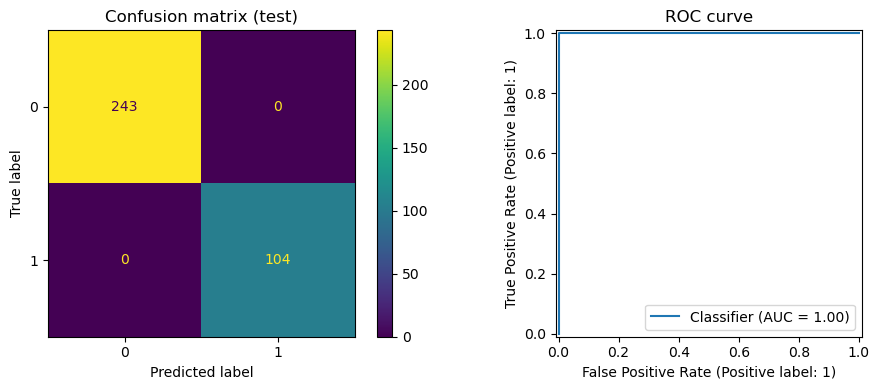

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title("Confusion matrix (test)")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC curve")
plt.tight_layout()
plt.show()

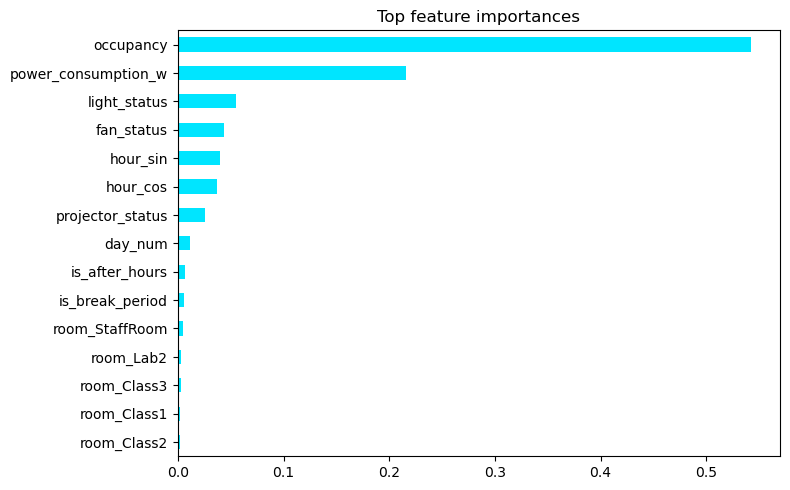

occupancy              0.542523
power_consumption_w    0.216020
light_status           0.055263
fan_status             0.043280
hour_sin               0.039519
hour_cos               0.036854
projector_status       0.025784
day_num                0.011086
is_after_hours         0.006850
is_break_period        0.005598
room_StaffRoom         0.004891
room_Lab2              0.003387
room_Class3            0.002938
room_Class1            0.002120
room_Class2            0.001958
dtype: float64

In [4]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot(kind="barh", ax=ax, color="#00e5ff")
ax.set_title("Top feature importances")
plt.tight_layout()
plt.show()
imp